# **Import file and Data cleansing**

In [1]:
# Mount drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Import library files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Connect the file to Google Drive for colab
df = pd.read_csv('/content/drive/My Drive/Internship projects/Major/signal_data.csv')

# Connect the file to local system for jupyter
# df = pd.read_csv('signal_data.csv')

In [4]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,581,582,583,584,585,586,587,588,589,Pass/Fail
count,1561.000000,1560.000000,1553.000000,1553.000000,1553.000000,1553.0,1553.000000,1558.000000,1565.000000,1565.000000,...,618.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1567.000000
mean,3014.452896,2495.850231,2200.547318,1396.376627,4.197013,100.0,101.112908,0.121822,1.462862,-0.000841,...,97.934373,0.500096,0.015318,0.003847,3.067826,0.021458,0.016475,0.005283,99.670066,-0.867262
std,73.621787,80.407705,29.513152,441.691640,56.355540,0.0,6.237214,0.008961,0.073897,0.015116,...,87.520966,0.003404,0.017180,0.003720,3.578033,0.012358,0.008808,0.002867,93.891919,0.498010
min,2743.240000,2158.750000,2060.660000,0.000000,0.681500,100.0,82.131100,0.000000,1.191000,-0.053400,...,0.000000,0.477800,0.006000,0.001700,1.197500,-0.016900,0.003200,0.001000,0.000000,-1.000000
25%,2966.260000,2452.247500,2181.044400,1081.875800,1.017700,100.0,97.920000,0.121100,1.411200,-0.010800,...,46.184900,0.497900,0.011600,0.003100,2.306500,0.013425,0.010600,0.003300,44.368600,-1.000000
50%,3011.490000,2499.405000,2201.066700,1285.214400,1.316800,100.0,101.512200,0.122400,1.461600,-0.001300,...,72.288900,0.500200,0.013800,0.003600,2.757650,0.020500,0.014800,0.004600,71.900500,-1.000000
75%,3056.650000,2538.822500,2218.055500,1591.223500,1.525700,100.0,104.586700,0.123800,1.516900,0.008400,...,116.539150,0.502375,0.016500,0.004100,3.295175,0.027600,0.020300,0.006400,114.749700,-1.000000
max,3356.350000,2846.440000,2315.266700,3715.041700,1114.536600,100.0,129.252200,0.128600,1.656400,0.074900,...,737.304800,0.509800,0.476600,0.104500,99.303200,0.102800,0.079900,0.028600,737.304800,1.000000


In [5]:
df.head()

,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


In [6]:
df.isnull().sum()

,0
Time,0
0,6
1,7
2,14
3,14
...,...
586,1
587,1
588,1
589,1


In [7]:
# Exclude the last column (assuming you have 592 columns)
df_main = df.iloc[:, :-1]  # This excludes the last column

# Separate the first column (column 0)
first_column = df.iloc[:, 0]

# Separate the middle columns (columns 2 to 591)
df_middle = df.iloc[:, 1:-1]

# Separate the last column (column 592)
last_column = df.iloc[:, -1]

# Display the middle columns to confirm
df_middle.head()

,0,1,2,3,4,5,6,7,8,9,...,580,581,582,583,584,585,586,587,588,589
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432


In [8]:

# Dynamically create column names for the first 591 columns
df_middle.columns = [f'Signal_{i+1}' for i in range(df_middle.shape[1])]

# Check the updated dataframe
df_middle.head()

,Signal_1,Signal_2,Signal_3,Signal_4,Signal_5,Signal_6,Signal_7,Signal_8,Signal_9,Signal_10,...,Signal_581,Signal_582,Signal_583,Signal_584,Signal_585,Signal_586,Signal_587,Signal_588,Signal_589,Signal_590
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432


In [9]:
# Handle missing values in the first 591 columns
for col in df_middle.columns:
    if df_middle[col].dtype == 'object':  # Check if the column is of object type (likely string)
        try:
            # Attempt to convert to datetime and then to numeric timestamps
            df_middle[col] = pd.to_datetime(df_middle[col]).astype(int) / 10**9
        except:
            pass  # If conversion fails, skip to the next column
df_middle.fillna(df_middle.mean(), inplace=True)

# Check for missing values after filling
df_middle.isnull().sum()

,0
Signal_1,0
Signal_2,0
Signal_3,0
Signal_4,0
Signal_5,0
...,...
Signal_586,0
Signal_587,0
Signal_588,0
Signal_589,0


In [10]:
df_main = df_middle
# Combine the cleaned first 591 columns with the last column
df_main = pd.concat([first_column,df_middle, last_column], axis=1)
# df_main = df_main.round()

# Check the final dataframe
df_main.head()

,Time,Signal_1,Signal_2,Signal_3,Signal_4,Signal_5,Signal_6,Signal_7,Signal_8,Signal_9,...,Signal_582,Signal_583,Signal_584,Signal_585,Signal_586,Signal_587,Signal_588,Signal_589,Signal_590,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,97.934373,0.5005,0.0118,0.0035,2.3630,0.021458,0.016475,0.005283,99.670066,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.204500,0.5019,0.0223,0.0055,4.4447,0.009600,0.020100,0.006000,208.204500,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.860200,0.4958,0.0157,0.0039,3.1745,0.058400,0.048400,0.014800,82.860200,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.843200,0.4990,0.0103,0.0025,2.0544,0.020200,0.014900,0.004400,73.843200,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,97.934373,0.4800,0.4766,0.1045,99.3032,0.020200,0.014900,0.004400,73.843200,-1


In [11]:
df  = df_main
df.head()

,Time,Signal_1,Signal_2,Signal_3,Signal_4,Signal_5,Signal_6,Signal_7,Signal_8,Signal_9,...,Signal_582,Signal_583,Signal_584,Signal_585,Signal_586,Signal_587,Signal_588,Signal_589,Signal_590,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,97.934373,0.5005,0.0118,0.0035,2.3630,0.021458,0.016475,0.005283,99.670066,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.204500,0.5019,0.0223,0.0055,4.4447,0.009600,0.020100,0.006000,208.204500,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.860200,0.4958,0.0157,0.0039,3.1745,0.058400,0.048400,0.014800,82.860200,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.843200,0.4990,0.0103,0.0025,2.0544,0.020200,0.014900,0.004400,73.843200,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,97.934373,0.4800,0.4766,0.1045,99.3032,0.020200,0.014900,0.004400,73.843200,-1


In [12]:
df.isnull().sum()

,0
Time,0
Signal_1,0
Signal_2,0
Signal_3,0
Signal_4,0
...,...
Signal_587,0
Signal_588,0
Signal_589,0
Signal_590,0


In [13]:
df.to_csv('New_df.csv', index=False)

#  **Data analysis & visualisation**

**1. Univariate Analysis**

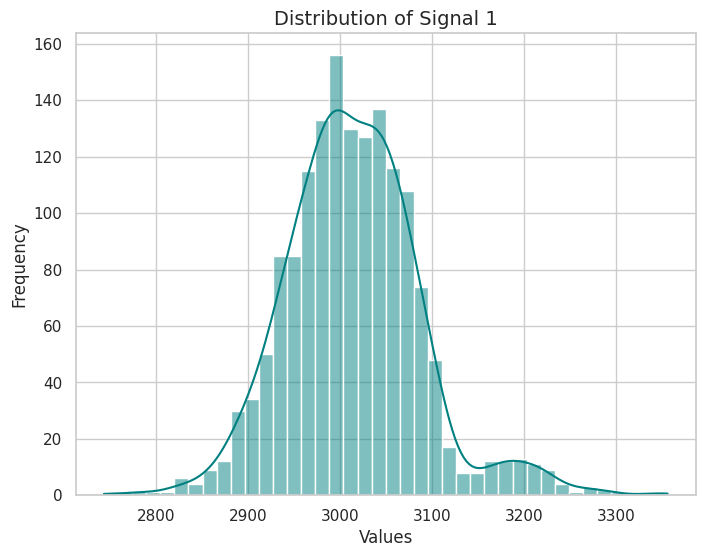

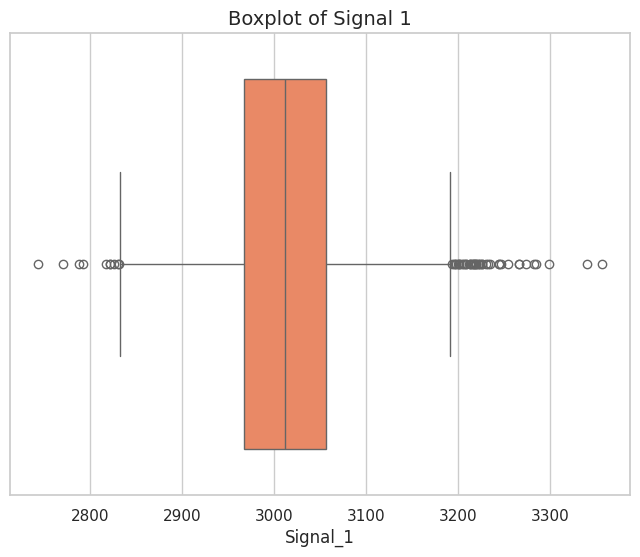

In [14]:
# Set a global Seaborn style
sns.set(style='whitegrid')

# Use a custom color palette
custom_palette = sns.color_palette("coolwarm", as_cmap=True)

# Example: Univariate analysis with a custom palette
plt.figure(figsize=(8, 6))
sns.histplot(df.iloc[:, 1], kde=True, color="teal")  # Change color to teal
plt.title('Distribution of Signal 1', fontsize=14)
plt.xlabel('Values', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

# Boxplot with a custom color
plt.figure(figsize=(8, 6))
sns.boxplot(x=df.iloc[:, 1], color='coral')  # Change color to coral
plt.title('Boxplot of Signal 1', fontsize=14)
plt.show()

**Conclusion**

*   The age distribution is approximately uniform with no significant skewness.
*   The mean value is 3014 closly.
*   We have a 50% data is 2970 to 3060.
*   Above 3190 most values are skewed.

**2. Bivariate Analysis**

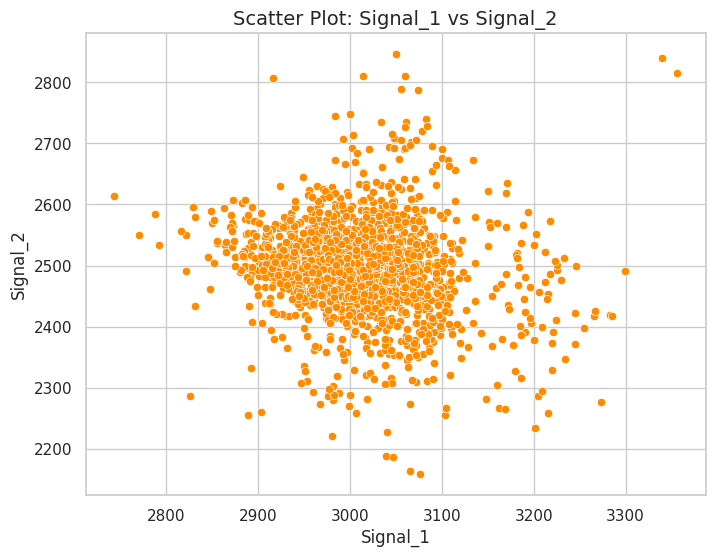

In [15]:
# Scatter plot with a custom color for points
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df.iloc[:, 1], y=df.iloc[:, 2], color='darkorange')  # Dark orange points
plt.title('Scatter Plot: Signal_1 vs Signal_2', fontsize=14)
plt.xlabel('Signal_1', fontsize=12)
plt.ylabel('Signal_2', fontsize=12)
plt.show()


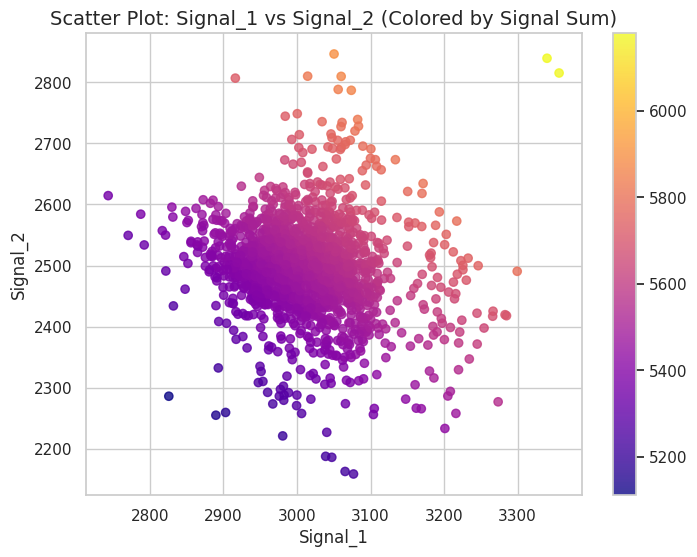

In [16]:
# Scatter plot with color based on both x and y values
plt.figure(figsize=(8, 6))

# Use the sum of x and y values to assign a color map
colors = df['Signal_1'] + df['Signal_2']  # You can choose other methods to combine x and y for color

# Plot with a colormap ('viridis' used here)
scatter = plt.scatter(df['Signal_1'], df['Signal_2'], c=colors, cmap='plasma', alpha=0.8)

# Add a color bar to show the mapping
plt.colorbar(scatter)

plt.title('Scatter Plot: Signal_1 vs Signal_2 (Colored by Signal Sum)', fontsize=14)
plt.xlabel('Signal_1', fontsize=12)
plt.ylabel('Signal_2', fontsize=12)
plt.show()

most signals of signal_1 is 3000 and signal_2 is 2500. So 500 is difference for this two columns. Signal_1 is having greater value compare to Signal_2 and Difference is 500.

In [17]:
df.iloc[:, 1]

,Signal_1
0,3030.93
1,3095.78
2,2932.61
3,2988.72
4,3032.24
...,...
1562,2899.41
1563,3052.31
1564,2978.81
1565,2894.92


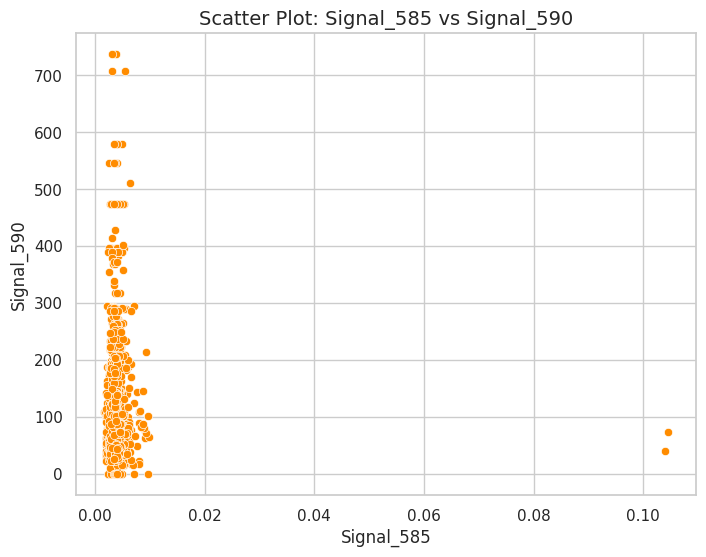

In [18]:
# Scatter plot with a custom color for points
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df.iloc[:, -7], y=df.iloc[:, -2], color='darkorange')  # Dark orange points
plt.title('Scatter Plot: Signal_585 vs Signal_590', fontsize=14)
plt.xlabel('Signal_585', fontsize=12)
plt.ylabel('Signal_590', fontsize=12)
plt.show()


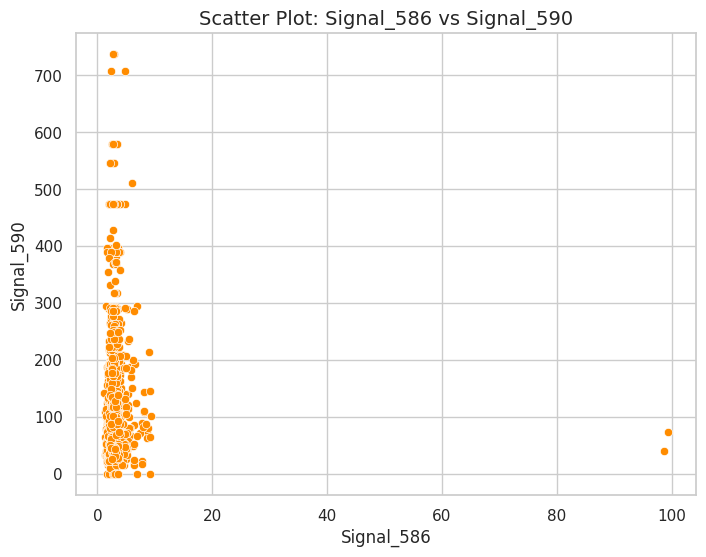

In [19]:
# Scatter plot with a custom color for points
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df.iloc[:, -6], y=df.iloc[:, -2], color='darkorange')  # Dark orange points
plt.title('Scatter Plot: Signal_586 vs Signal_590', fontsize=14)
plt.xlabel('Signal_586', fontsize=12)
plt.ylabel('Signal_590', fontsize=12)
plt.show()

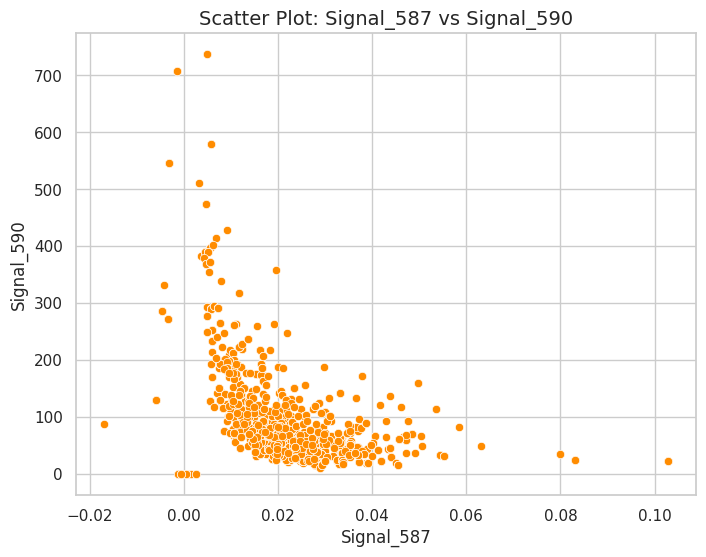

In [20]:
# Scatter plot with a custom color for points
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df.iloc[:, -5], y=df.iloc[:, -2], color='darkorange')  # Dark orange points
plt.title('Scatter Plot: Signal_587 vs Signal_590', fontsize=14)
plt.xlabel('Signal_587', fontsize=12)
plt.ylabel('Signal_590', fontsize=12)
plt.show()

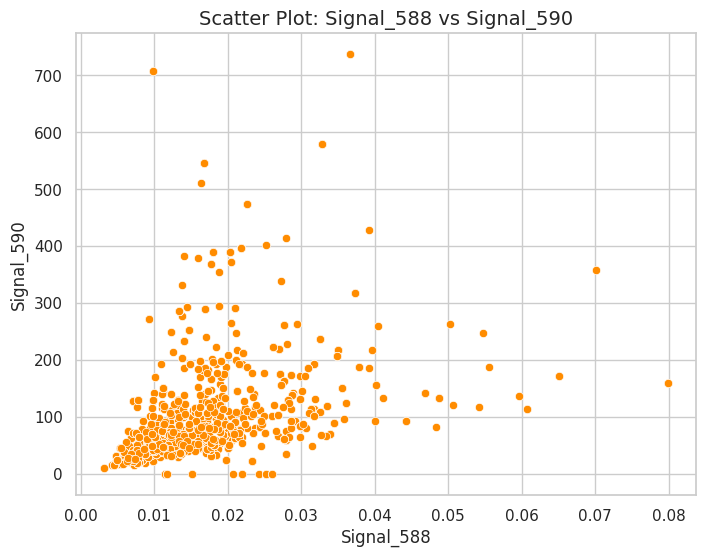

In [21]:
# Scatter plot with a custom color for points
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df.iloc[:, -4], y=df.iloc[:, -2], color='darkorange')  # Dark orange points
plt.title('Scatter Plot: Signal_588 vs Signal_590', fontsize=14)
plt.xlabel('Signal_588', fontsize=12)
plt.ylabel('Signal_590', fontsize=12)
plt.show()

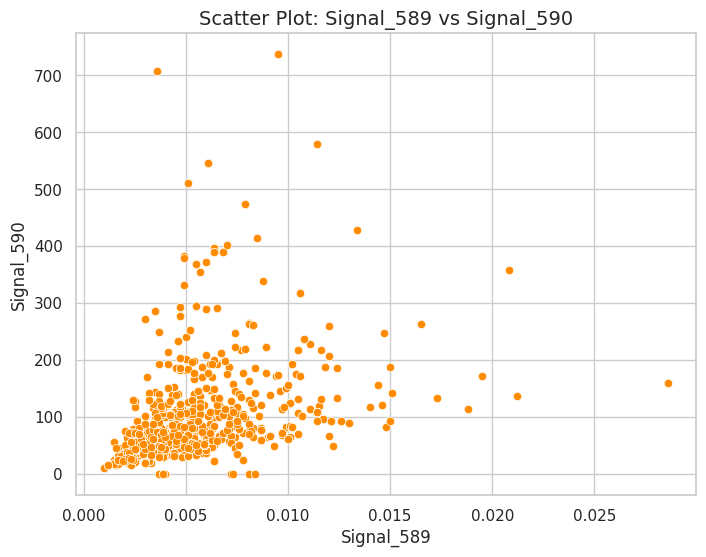

In [22]:
# Scatter plot with a custom color for points
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df.iloc[:, -3], y=df.iloc[:, -2], color='darkorange')  # Dark orange points
plt.title('Scatter Plot: Signal_589 vs Signal_590', fontsize=14)
plt.xlabel('Signal_589', fontsize=12)
plt.ylabel('Signal_590', fontsize=12)
plt.show()

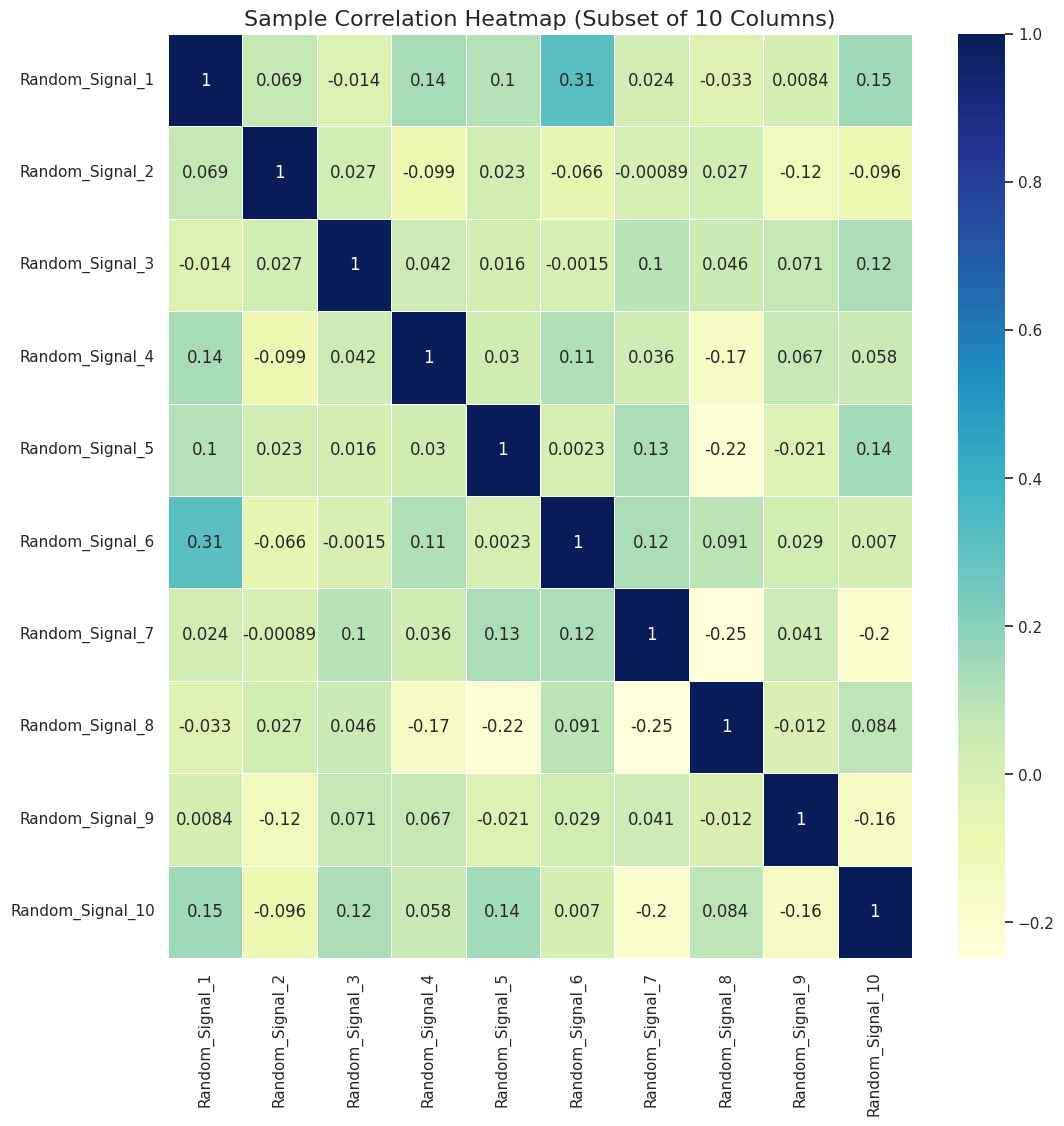

In [23]:
# Step 1: Create a large DataFrame with 590 columns and 100 rows of random data
np.random.seed(42)  # For reproducibility
data = np.random.rand(100, 590)  # 100 rows, 590 columns

# Create a DataFrame with column names like 'Feature_1', 'Feature_2', ..., 'Feature_590'
columns = [f'Random_Signal_{i}' for i in range(1, 591)]
df_large = pd.DataFrame(data, columns=columns)

# Step 2: Calculate the correlation matrix for the DataFrame (optional: subset)
# For readability, let's visualize a subset of the columns (first 20)
df_subset = df_large.iloc[:, :10]  # Select first 20 columns for heatmap visualization

correlation_matrix_subset = df_subset.corr()

# Step 3: Plot the heatmap for the subset of the columns
plt.figure(figsize=(12, 12))
sns.heatmap(correlation_matrix_subset, annot=True, cmap='YlGnBu', linewidths=0.5)
plt.title('Sample Correlation Heatmap (Subset of 10 Columns)', fontsize=16)
plt.show()

**3. Multivariate Analysis**

In [24]:
df.head()

,Time,Signal_1,Signal_2,Signal_3,Signal_4,Signal_5,Signal_6,Signal_7,Signal_8,Signal_9,...,Signal_582,Signal_583,Signal_584,Signal_585,Signal_586,Signal_587,Signal_588,Signal_589,Signal_590,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,97.934373,0.5005,0.0118,0.0035,2.3630,0.021458,0.016475,0.005283,99.670066,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.204500,0.5019,0.0223,0.0055,4.4447,0.009600,0.020100,0.006000,208.204500,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.860200,0.4958,0.0157,0.0039,3.1745,0.058400,0.048400,0.014800,82.860200,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.843200,0.4990,0.0103,0.0025,2.0544,0.020200,0.014900,0.004400,73.843200,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,97.934373,0.4800,0.4766,0.1045,99.3032,0.020200,0.014900,0.004400,73.843200,-1


<Figure size 1200x1200 with 0 Axes>

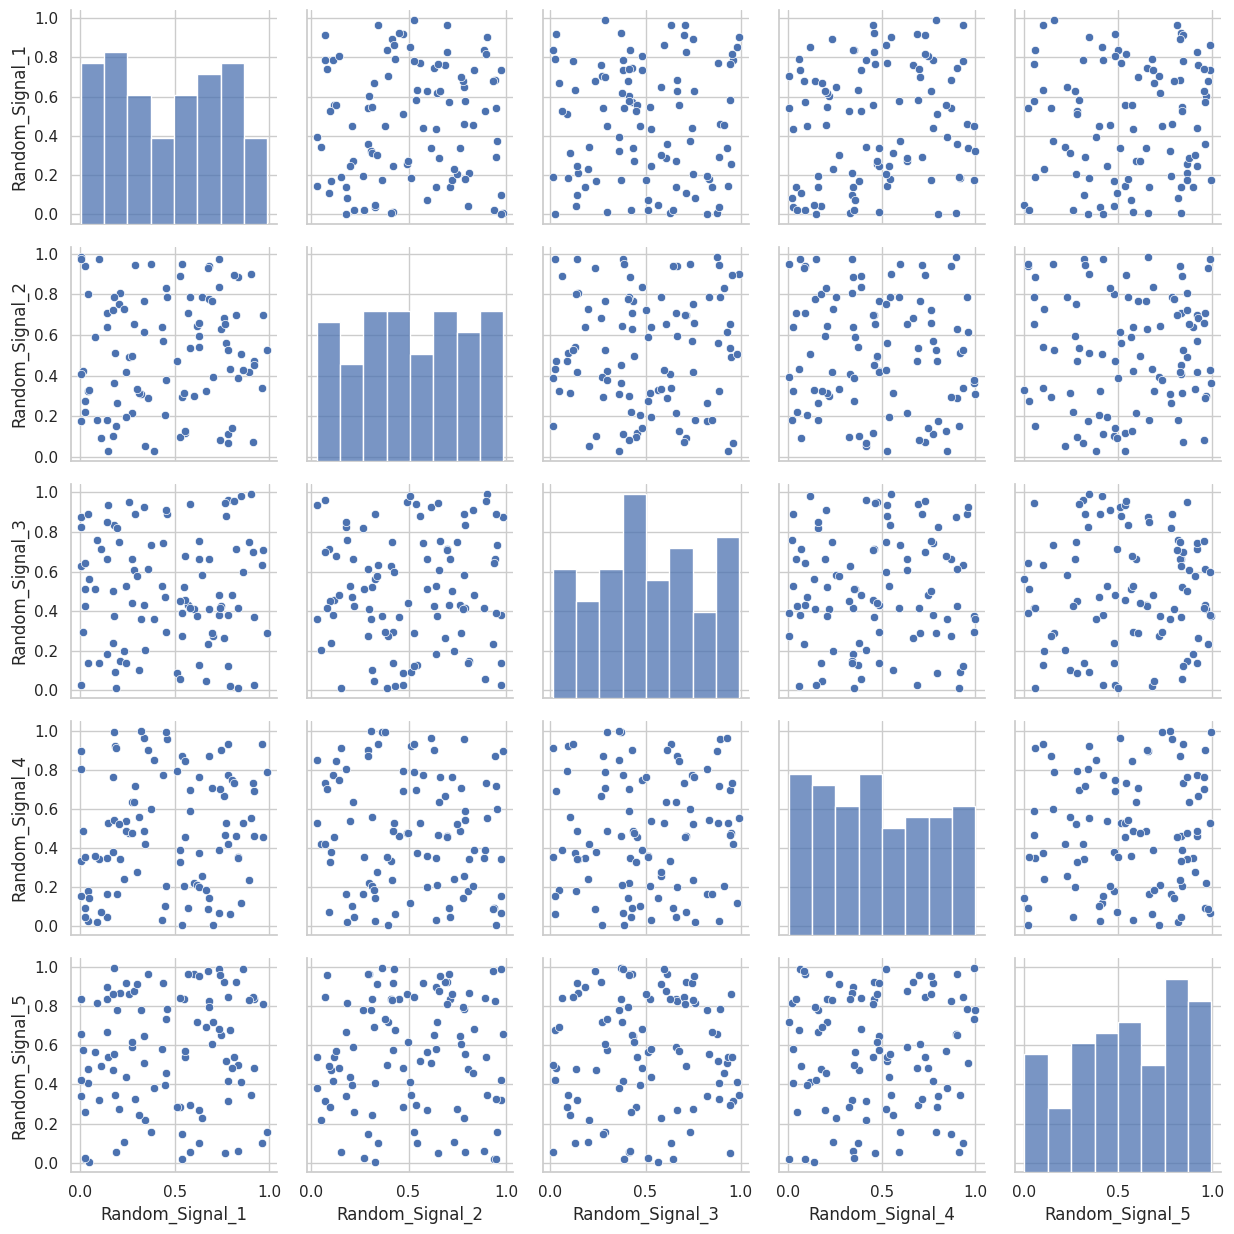

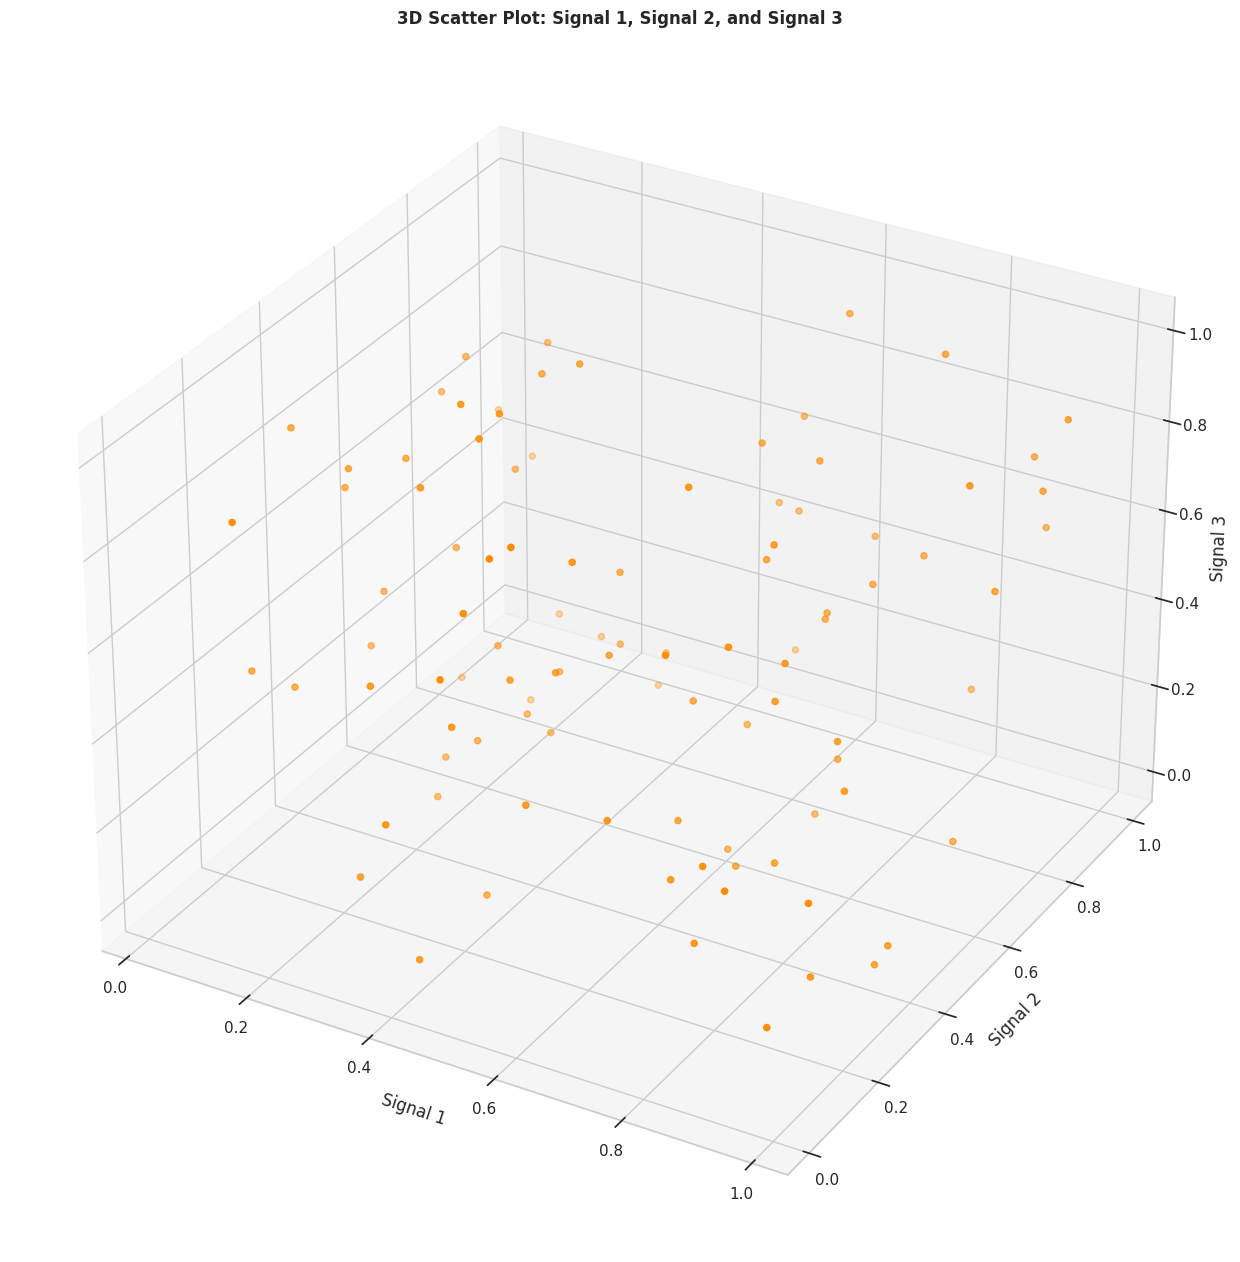

In [25]:
df_subset = df_large.iloc[:, :10]

# Pair plot for the subset of columns
fig = plt.figure(figsize=(12, 12))
sns.pairplot(df_subset.iloc[:, 0:5])  # Plot for columns 1 to 5
# plt.title('Pair Plot for Multiple Columns')
plt.tight_layout()
plt.show()

# Add comments: Analyze pair plots and comment on relationships, clusters, and patterns.

# For 3D scatter plot (if applicable)
from mpl_toolkits.mplot3d import Axes3D

# 3D scatter plot for three variables
fig = plt.figure(figsize=(16, 15.85))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df_subset.iloc[:, 1], df_subset.iloc[:, 2], df_subset.iloc[:, 3], c='darkorange', marker='o')
ax.set_xlabel('Signal 1')
ax.set_ylabel('Signal 2')
ax.set_zlabel('Signal 3')
plt.title('3D Scatter Plot: Signal 1, Signal 2, and Signal 3',fontweight='bold')
# plt.tight_layout()
plt.show()

# Add comments: Discuss any notable relationships or clusters in the multivariate data.


# **Data pre-processing:**

In [26]:
df.head()

,Time,Signal_1,Signal_2,Signal_3,Signal_4,Signal_5,Signal_6,Signal_7,Signal_8,Signal_9,...,Signal_582,Signal_583,Signal_584,Signal_585,Signal_586,Signal_587,Signal_588,Signal_589,Signal_590,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,97.934373,0.5005,0.0118,0.0035,2.3630,0.021458,0.016475,0.005283,99.670066,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.204500,0.5019,0.0223,0.0055,4.4447,0.009600,0.020100,0.006000,208.204500,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.860200,0.4958,0.0157,0.0039,3.1745,0.058400,0.048400,0.014800,82.860200,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.843200,0.4990,0.0103,0.0025,2.0544,0.020200,0.014900,0.004400,73.843200,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,97.934373,0.4800,0.4766,0.1045,99.3032,0.020200,0.014900,0.004400,73.843200,-1


In [27]:
# # import pandas as pd       # I already importin this library
# from imblearn.over_sampling import SMOTE
# from collections import Counter

# # Assuming 'df' is your DataFrame and it has a datetime column named 'Time'
# # Ensure the column is of datetime type
# df['Time'] = pd.to_datetime(df['Time'])

# # Convert datetime columns to numerical features (e.g., Unix timestamp)
# df['Time'] = pd.to_numeric(df['Time'].astype(int))

# # Assuming 'df' is your DataFrame, and 'target_column' is the column you're predicting
# X = df.drop('Signal_590', axis=1)  # Predictors
# y = df['Pass/Fail']               # Target

# smote = SMOTE(random_state=42)
# X_resampled, y_resampled = smote.fit_resample(X, y)

# print(Counter(y_resampled))  # After SMOTE, the target classes will be balanced

In [28]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from collections import Counter

# Assuming 'df' is your DataFrame and it has a datetime column named 'Time'
# Ensure the 'Time' column is of datetime type
df['Time'] = pd.to_datetime(df['Time'])

# Convert 'Time' column to Unix timestamp
df['Time'] = df['Time'].view(int) / 10**9  # Convert to seconds since epoch

# Specify the column that should remain categorical (let's say it's named 'Category' in your case)
categorical_column = df.columns[0]  # The first column remains unchanged

# Keep the first column unchanged and drop the 'Signal_590' column for prediction
X = df.drop('Signal_590', axis=1)

# Assuming the last column is the 'Pass/Fail' (target)
y = df['Pass/Fail']

# Apply SMOTE to the predictors and target (ignoring the categorical column)
smote = SMOTE(random_state=42)

# Before applying SMOTE, make sure the categorical column is processed appropriately
X_resampled, y_resampled = smote.fit_resample(X, y)

# Output the class distribution after resampling
print(Counter(y_resampled))

<ipython-input-28-fece1307fbbf>:10: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  df['Time'] = df['Time'].view(int) / 10**9  # Convert to seconds since epoch


Counter({-1: 1463, 1: 1463})


In [29]:
df.head()

,Time,Signal_1,Signal_2,Signal_3,Signal_4,Signal_5,Signal_6,Signal_7,Signal_8,Signal_9,...,Signal_582,Signal_583,Signal_584,Signal_585,Signal_586,Signal_587,Signal_588,Signal_589,Signal_590,Pass/Fail
0,1.216468e+09,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,97.934373,0.5005,0.0118,0.0035,2.3630,0.021458,0.016475,0.005283,99.670066,-1
1,1.216471e+09,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.204500,0.5019,0.0223,0.0055,4.4447,0.009600,0.020100,0.006000,208.204500,-1
2,1.216473e+09,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.860200,0.4958,0.0157,0.0039,3.1745,0.058400,0.048400,0.014800,82.860200,1
3,1.216479e+09,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.843200,0.4990,0.0103,0.0025,2.0544,0.020200,0.014900,0.004400,73.843200,-1
4,1.216481e+09,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,97.934373,0.4800,0.4766,0.1045,99.3032,0.020200,0.014900,0.004400,73.843200,-1


In [30]:
# Perform Train-Test Split and Standardize the Data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Standardizing the data (only predictors, not the target)
scaler = StandardScaler()

# Fit the scaler on the training data, then apply the transformation
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [31]:
# Check if Train and Test Data Have Similar Statistical Characteristics:

# Statistical summary of the original data
print("Original data statistics:")
print(X.describe())

# Statistical summary of the train set
print("Train data statistics:")
print(pd.DataFrame(X_train_scaled, columns=X.columns).describe())

# Statistical summary of the test set
print("Test data statistics:")
print(pd.DataFrame(X_test_scaled, columns=X.columns).describe())


Original data statistics:
               Time     Signal_1     Signal_2     Signal_3     Signal_4  \
count  1.567000e+03  1567.000000  1567.000000  1567.000000  1567.000000   
mean   1.217454e+09  3014.452896  2495.850231  2200.547318  1396.376627   
std    7.023985e+06    73.480613    80.227793    29.380932   439.712852   
min    1.199758e+09  2743.240000  2158.750000  2060.660000     0.000000   
25%    1.215618e+09  2966.665000  2452.885000  2181.099950  1083.885800   
50%    1.219497e+09  3011.840000  2498.910000  2200.955600  1287.353800   
75%    1.222082e+09  3056.540000  2538.745000  2218.055500  1590.169900   
max    1.228935e+09  3356.350000  2846.440000  2315.266700  3715.041700   

          Signal_5  Signal_6     Signal_7     Signal_8     Signal_9  ...  \
count  1567.000000    1567.0  1567.000000  1567.000000  1567.000000  ...   
mean      4.197013     100.0   101.112908     0.121822     1.462862  ...   
std      56.103066       0.0     6.209271     0.008936     0.073849  .

# **Model training, testing and tuning:**

In [32]:
df.head()

,Time,Signal_1,Signal_2,Signal_3,Signal_4,Signal_5,Signal_6,Signal_7,Signal_8,Signal_9,...,Signal_582,Signal_583,Signal_584,Signal_585,Signal_586,Signal_587,Signal_588,Signal_589,Signal_590,Pass/Fail
0,1.216468e+09,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,97.934373,0.5005,0.0118,0.0035,2.3630,0.021458,0.016475,0.005283,99.670066,-1
1,1.216471e+09,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.204500,0.5019,0.0223,0.0055,4.4447,0.009600,0.020100,0.006000,208.204500,-1
2,1.216473e+09,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.860200,0.4958,0.0157,0.0039,3.1745,0.058400,0.048400,0.014800,82.860200,1
3,1.216479e+09,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.843200,0.4990,0.0103,0.0025,2.0544,0.020200,0.014900,0.004400,73.843200,-1
4,1.216481e+09,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,97.934373,0.4800,0.4766,0.1045,99.3032,0.020200,0.014900,0.004400,73.843200,-1


In [33]:
## if we want want rename 1 and -1.

# y =y.map({-1: 'Fail', 1: 'Pass'})

# print(y)

Pass/Fail
-1    1463
 1     104
Name: count, dtype: int64


<ipython-input-34-468359ac45c4>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='Set2')


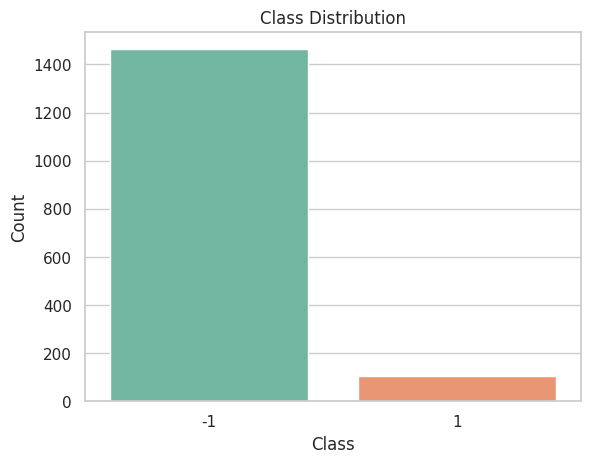

In [34]:
# Check the class distribution
print(y.value_counts())

# Visualizing the imbalance
sns.countplot(x=y, palette='Set2')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [35]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to balance the classes
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Check the balanced class distribution
print(y_resampled.value_counts())

Pass/Fail
-1    1463
 1    1463
Name: count, dtype: int64


In [36]:
from sklearn.model_selection import train_test_split

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)


In [37]:
# Standardize the data (fit on training data, transform both train and test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Original Data Statistics:
                Time     Signal_1     Signal_2     Signal_3     Signal_4  \
count  1.567000e+03  1567.000000  1567.000000  1567.000000  1567.000000   
mean   1.217454e+09  3014.452896  2495.850231  2200.547318  1396.376627   
std    7.023985e+06    73.480613    80.227793    29.380932   439.712852   
min    1.199758e+09  2743.240000  2158.750000  2060.660000     0.000000   
25%    1.215618e+09  2966.665000  2452.885000  2181.099950  1083.885800   
50%    1.219497e+09  3011.840000  2498.910000  2200.955600  1287.353800   
75%    1.222082e+09  3056.540000  2538.745000  2218.055500  1590.169900   
max    1.228935e+09  3356.350000  2846.440000  2315.266700  3715.041700   

          Signal_5  Signal_6     Signal_7     Signal_8     Signal_9  ...  \
count  1567.000000    1567.0  1567.000000  1567.000000  1567.000000  ...   
mean      4.197013     100.0   101.112908     0.121822     1.462862  ...   
std      56.103066       0.0     6.209271     0.008936     0.073849  

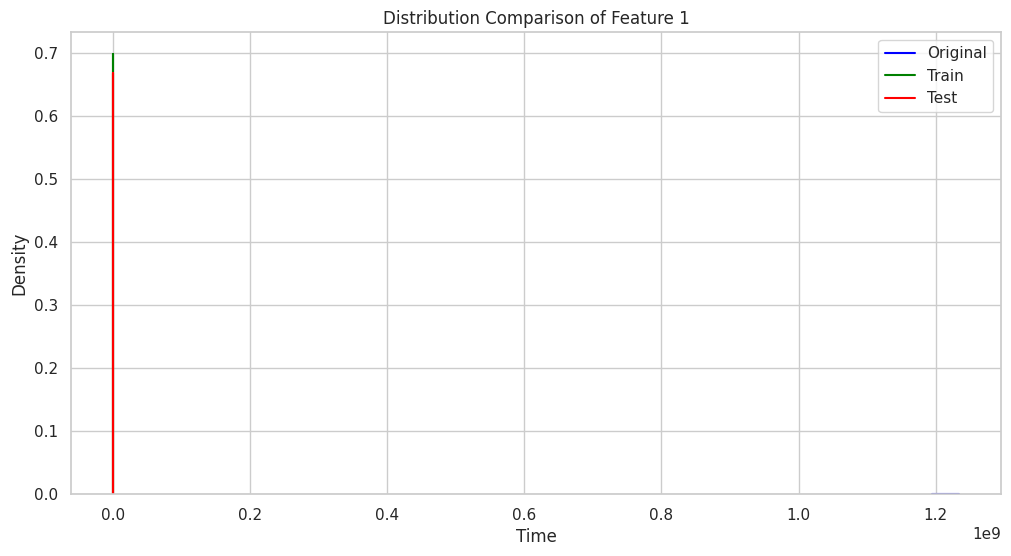

In [38]:
# Check statistics of the original, train, and test data
print("Original Data Statistics:\n", X.describe())
print("Training Data Statistics:\n", pd.DataFrame(X_train_scaled).describe())
print("Test Data Statistics:\n", pd.DataFrame(X_test_scaled).describe())

# Visual comparison (optional)

# Plot original vs training vs test distributions for a selected feature
plt.figure(figsize=(12, 6))
sns.kdeplot(X.iloc[:, 0], label='Original', color='blue')
sns.kdeplot(X_train_scaled[:, 0], label='Train', color='green')
sns.kdeplot(X_test_scaled[:, 0], label='Test', color='red')
plt.title('Distribution Comparison of Feature 1')
plt.legend()
plt.show()


#  **Conclusion and improvisation:**

**Sample Conclusion:**

In this project, we applied data science techniques to a semiconductor manufacturing problem, focusing on identifying key sensor signals that affect the yield type. By utilizing feature selection and predictive modeling, we were able to pinpoint the most important signals, reducing noise and improving model accuracy. This resulted in significant gains in process efficiency, enabling faster learning and reducing production costs. Our approach demonstrates the power of data science in transforming manufacturing processes and enhancing overall productivity.